### Import the Basic Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

--- Or import the libraries from mine py ---

In [2]:
import sys
sys.path.append(r'C:\Users\User\005_Libraries')

import mylibs

In [3]:
katarina_classic= 'katarina_matches_1000.csv'
df_kata= pd.read_csv(katarina_classic)
df_kata

,game_duration,win,kills,deaths,assists,cs,gold_earned,damage_to_champions,damage_taken,level,...,team_barons,team_towers,first_blood,kda_ratio,cs_per_min,gold_per_min,damage_per_min,kill_participation,kill_share,death_share
0,1978,0,11,5,2,236,15778,26594,24002,18,...,1,7,0,2.60,7.16,478.60,806.69,0.406,0.344,0.161
1,1725,0,7,3,1,203,11595,16284,18857,16,...,1,3,1,2.67,7.06,403.30,566.40,0.276,0.241,0.073
2,2020,1,11,2,8,148,13404,24535,21070,17,...,1,8,1,9.50,4.40,398.14,728.76,0.487,0.282,0.091
3,944,0,1,6,0,59,3971,4494,12750,9,...,0,0,1,0.17,3.75,252.39,285.64,0.333,0.333,0.333
4,1670,0,1,3,4,174,8590,7802,13334,15,...,0,1,0,1.67,6.25,308.62,280.31,0.333,0.067,0.088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,1544,0,6,8,2,108,8339,16536,23204,12,...,0,2,0,1.00,4.20,324.05,642.59,0.258,0.194,0.205
456,1648,1,22,0,7,173,15854,32460,17529,17,...,0,9,1,29.00,6.30,577.21,1181.80,0.644,0.489,0.000
457,2217,0,13,4,8,212,16518,33320,30088,17,...,0,4,1,5.25,5.74,447.04,901.76,0.553,0.342,0.095
458,1645,0,13,4,1,197,14540,23854,24872,15,...,0,3,0,3.50,7.19,530.33,870.05,0.500,0.464,0.121


In [6]:
print(f"\n Dataset loaded: {len(df_kata)} games")
print(f" Win Rate: {df_kata['win'].mean()*100:.1f}%")


 Dataset loaded: 460 games
 Win Rate: 51.1%


### Correlation Heatmap


 CORRELATION WITH WINNING (sorted):
win                    1.000000
team_towers            0.704818
team_dragons           0.645968
kda_ratio              0.497622
team_barons            0.461107
gold_per_min           0.449015
damage_per_min         0.379291
kills                  0.352649
assists                0.338927
damage_to_champions    0.269059
gold_earned            0.239291
level                  0.215563
first_blood            0.147123
kill_participation     0.146591
kill_share             0.082053
game_duration          0.079084
cs                     0.076099
cs_per_min             0.067807
damage_taken           0.037759
death_share            0.003596
deaths                -0.285293
Name: win, dtype: float64

TOP 10 POSITIVE CORRELATIONS WITH WINNING:
 1. team_towers              : +0.705
 2. team_dragons             : +0.646
 3. kda_ratio                : +0.498
 4. team_barons              : +0.461
 5. gold_per_min             : +0.449
 6. damage_per_min           : 

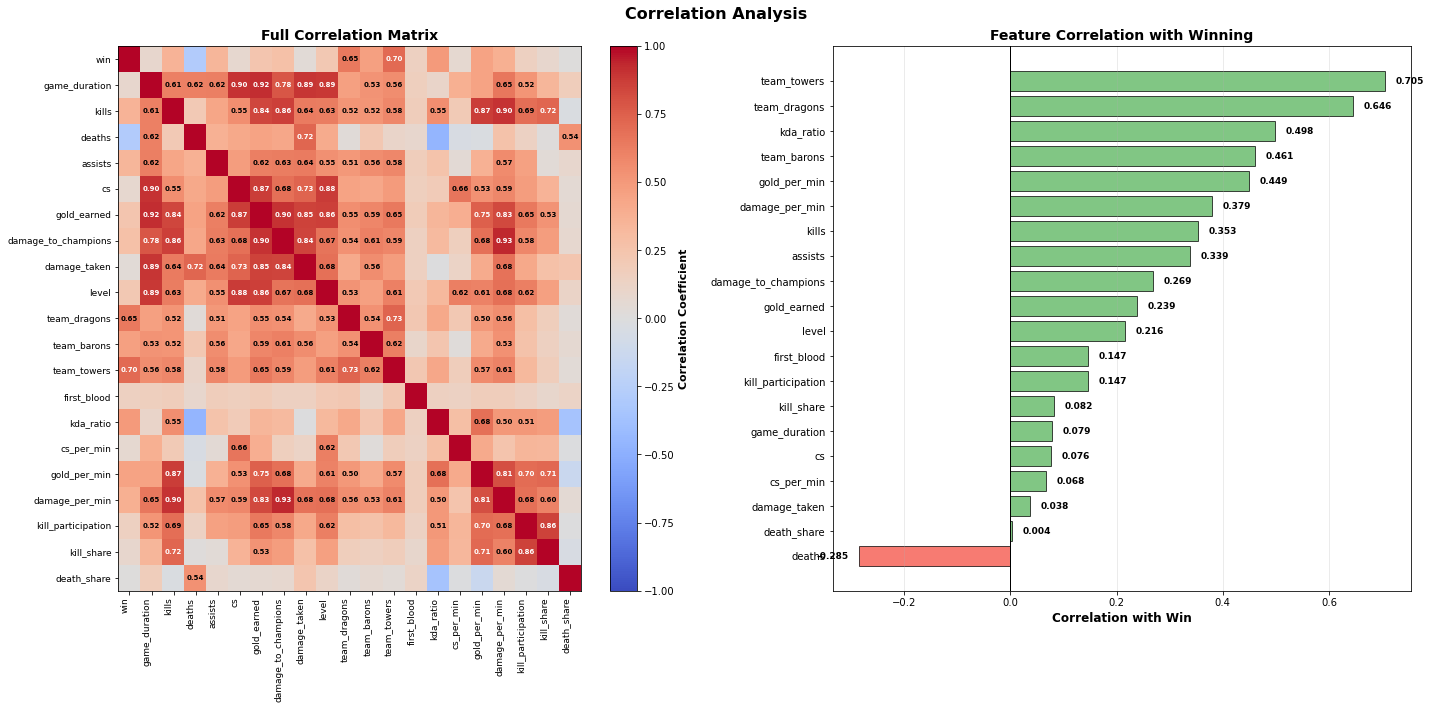


CORRELATION BY FEATURE GROUPS:

 YOUR PERFORMANCE:
   kills                    : +0.353
   deaths                   : -0.285
   assists                  : +0.339
   kda_ratio                : +0.498
   kill_participation       : +0.147
   kill_share               : +0.082
   death_share              : +0.004

 GOLD:
   cs                       : +0.076
   cs_per_min               : +0.068
   gold_earned              : +0.239
   gold_per_min             : +0.449

 COMBAT:
   damage_to_champions      : +0.269
   damage_per_min           : +0.379
   damage_taken             : +0.038
   level                    : +0.216

 TEAM OBJECTIVES:
   team_dragons             : +0.646
   team_barons              : +0.461
   team_towers              : +0.705
   first_blood              : +0.147

 GAME CONTEXT:
   game_duration            : +0.079

HIGHLY CORRELATED FEATURES (Multicollinearity):
Features with correlation > 0.8 (excluding 'win'):
   damage_to_champions       <-> damage_per_min        

In [20]:
# Select numeric features for correlation analysis
numeric_features= ['win', 'game_duration', 'kills', 'deaths', 'assists', 
                   'cs', 'gold_earned', 'damage_to_champions', 'damage_taken', 
                   'level', 'team_dragons', 'team_barons', 'team_towers', 
                   'first_blood', 'kda_ratio', 'cs_per_min', 'gold_per_min', 
                   'damage_per_min', 'kill_participation', 'kill_share', 'death_share']

correlation_matrix= df_kata[numeric_features].corr()

# Get correlation with 'win' and sort
correlation_with_win= correlation_matrix['win'].sort_values(ascending=False)

print(f"\n CORRELATION WITH WINNING (sorted):")
print("="*60)
print(correlation_with_win)

print(f"\n {'='*60}")
print("TOP 10 POSITIVE CORRELATIONS WITH WINNING:")
print("="*60)

# Exclude 'win' itself
top_10_positive= correlation_with_win[1:11]
for i, (feature, corr) in enumerate(top_10_positive.items(), 1):
    print(f"{i:2d}. {feature:25s}: {corr:+.3f}")

print(f"\n {'='*60}")
print("TOP 5 NEGATIVE CORRELATIONS WITH WINNING:")
print("="*60)
bottom_5_negative= correlation_with_win[-5:]
for i, (feature, corr) in enumerate(bottom_5_negative.items(), 1):
    print(f"{i:2d}. {feature:25s}: {corr:+.3f}")

# Create comprehensive heatmap
fig, axes= plt.subplots(1, 2, figsize= (20, 10))
fig.suptitle('Correlation Analysis', fontsize= 16, fontweight= 'bold')

# 1. Full correlation heatmap
im1= axes[0].imshow(correlation_matrix, cmap= 'coolwarm', aspect= 'auto', vmin= -1, vmax= 1)
axes[0].set_xticks(range(len(numeric_features)))
axes[0].set_yticks(range(len(numeric_features)))
axes[0].set_xticklabels(numeric_features, rotation= 90, ha= 'right', fontsize= 9)
axes[0].set_yticklabels(numeric_features, fontsize= 9)
axes[0].set_title('Full Correlation Matrix', fontsize= 14, fontweight= 'bold')

cbar1= plt.colorbar(im1, ax= axes[0])
cbar1.set_label('Correlation Coefficient', fontsize= 11, fontweight= 'bold')

# Add correlation values (only for high correlations to avoid clutter)
for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        corr_val= correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5 and i != j: 
            text_color= 'white' if abs(corr_val) > 0.7 else 'black'
            axes[0].text(j, i, f'{corr_val:.2f}', 
                        ha= 'center', va= 'center', 
                        color= text_color, fontsize= 7, fontweight= 'bold')

# 2. Correlation with Win (bar chart)
# Exclude 'win' itself
win_corr_sorted= correlation_with_win[1:].sort_values()  
colors= ['#F44336' if x < 0 else '#4CAF50' for x in win_corr_sorted.values]

axes[1].barh(range(len(win_corr_sorted)), win_corr_sorted.values, color= colors, alpha= 0.7, edgecolor= 'black')
axes[1].set_yticks(range(len(win_corr_sorted)))
axes[1].set_yticklabels(win_corr_sorted.index, fontsize= 10)
axes[1].axvline(x= 0, color= 'black', linestyle= '-', linewidth= 1)
axes[1].set_xlabel('Correlation with Win', fontsize= 12, fontweight= 'bold')
axes[1].set_title('Feature Correlation with Winning', fontsize= 14, fontweight= 'bold')
axes[1].grid(axis= 'x', alpha= 0.3)

for i, (feature, corr) in enumerate(win_corr_sorted.items()):
    x_pos= corr + (0.02 if corr > 0 else -0.02)
    ha= 'left' if corr > 0 else 'right'
    axes[1].text(x_pos, i, f'{corr:.3f}', 
                ha= ha, va= 'center', fontsize= 9, fontweight= 'bold')

plt.tight_layout()
plt.show()

# Additional analysis: Feature groups
print(f"\n{'='*60}")
print("CORRELATION BY FEATURE GROUPS:")
print("="*60)

# Group 1: Your Performance
performance_features= ['kills', 'deaths', 'assists', 'kda_ratio', 
                       'kill_participation', 'kill_share', 'death_share']
print(f"\n YOUR PERFORMANCE:")
for feat in performance_features:
    if feat in correlation_with_win.index:
        print(f"   {feat:25s}: {correlation_with_win[feat]:+.3f}")

# Group 2: Gold
economy_features= ['cs', 'cs_per_min', 'gold_earned', 'gold_per_min']
print(f"\n GOLD:")
for feat in economy_features:
    if feat in correlation_with_win.index:
        print(f"   {feat:25s}: {correlation_with_win[feat]:+.3f}")

# Group 3: Combat
combat_features= ['damage_to_champions', 'damage_per_min', 'damage_taken', 'level']
print(f"\n COMBAT:")
for feat in combat_features:
    if feat in correlation_with_win.index:
        print(f"   {feat:25s}: {correlation_with_win[feat]:+.3f}")

# Group 4: Team Objectives
objective_features= ['team_dragons', 'team_barons', 'team_towers', 'first_blood']
print(f"\n TEAM OBJECTIVES:")
for feat in objective_features:
    if feat in correlation_with_win.index:
        print(f"   {feat:25s}: {correlation_with_win[feat]:+.3f}")

# Group 5: Game Context
context_features= ['game_duration']
print(f"\n GAME CONTEXT:")
for feat in context_features:
    if feat in correlation_with_win.index:
        print(f"   {feat:25s}: {correlation_with_win[feat]:+.3f}")

# Multicollinearity check
print(f"\n{'='*60}")
print("HIGHLY CORRELATED FEATURES (Multicollinearity):")
print("="*60)
print("Features with correlation > 0.8 (excluding 'win'):")

high_corr_pairs= []
for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        feat1= numeric_features[i]
        feat2= numeric_features[j]
        if feat1 != 'win' and feat2 != 'win':
            corr_val= correlation_matrix.loc[feat1, feat2]
            if abs(corr_val) > 0.8:
                high_corr_pairs.append((feat1, feat2, corr_val))

if high_corr_pairs:
    for feat1, feat2, corr in sorted(high_corr_pairs, key= lambda x: abs(x[2]), reverse= True):
        print(f"   {feat1:25s} <-> {feat2:25s}: {corr:+.3f}")
else:
    print("No highly correlated feature pairs found!")

# Summary
print(f"\n {'='*60}")
print("KEY FINDINGS SUMMARY:")
print("="*60)

strongest_positive= correlation_with_win[1:4]
strongest_negative= correlation_with_win[-3:]

print(f"\n STRONGEST POSITIVE PREDICTORS:")
for i, (feat, corr) in enumerate(strongest_positive.items(), 1):
    print(f"{i}. {feat}: {corr:+.3f}")

print(f"\n STRONGEST NEGATIVE PREDICTORS:")
for i, (feat, corr) in enumerate(strongest_negative.items(), 1):
    print(f"{i}. {feat}: {corr:+.3f}")

print(f"\n INSIGHTS:")
print(f"- Top predictor: {correlation_with_win.index[1]} ({correlation_with_win.iloc[1]:+.3f})")
print(f"- Weakest predictor: {correlation_with_win.index[-1]} ({correlation_with_win.iloc[-1]:+.3f})")
print(f"- Range: {correlation_with_win.iloc[-1]:.3f} to {correlation_with_win.iloc[1]:+.3f}")

### Features Selection (High Correlation with Win)

In [21]:
selected_features= [
    # Team Objectives (TOP predictors!)
    'team_towers',
    'team_dragons',
    'team_barons',
    
    # Performance
    'kda_ratio',
    'kills',
    'deaths',
    'assists',
    
    # Gold & Combat
    'gold_per_min',
    'damage_per_min',
    
    # Knowledge from experience (moderate correlation)
    'first_blood',
    'level',
]

In [28]:
print(f"\n Selected {len(selected_features)} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i:2d}. {feat}")


 Selected 11 features:
 1. team_towers
 2. team_dragons
 3. team_barons
 4. kda_ratio
 5. kills
 6. deaths
 7. assists
 8. gold_per_min
 9. damage_per_min
10. first_blood
11. level


### Prepare X (features) and y (target)

In [29]:
X= df_kata[selected_features]
y= df_kata['win']

### Train/Test Split (80/20)

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

In [35]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train_sc= sc.fit_transform(X_train)
X_test_sc= sc.fit_transform(X_test)

In [48]:
# Display feature statistics
print(f"\n FEATURE STATISTICS (Training Set):")
print("="*60)
feature_stats= pd.DataFrame({
    'Feature': selected_features,
    'Mean': X_train.mean().round(2),
    'Std': X_train.std().round(2),
    'Min': X_train.min(),
    'Max': X_train.max()
})

feature_stats_sc= pd.DataFrame({
    'Feature': selected_features,
    'Mean': X_train_sc.mean().round(2),
    'Std': X_train_sc.std().round(2),
    'Min': X_train_sc.min(),
    'Max': X_train_sc.max()
})

print(feature_stats.to_string(index= False))
print(f"\n {feature_stats_sc.to_string(index= False)}")


 FEATURE STATISTICS (Training Set):
       Feature   Mean    Std    Min     Max
   team_towers   5.63   3.81   0.00   16.00
  team_dragons   1.85   1.41   0.00    5.00
   team_barons   0.46   0.63   0.00    3.00
     kda_ratio   5.72   6.06   0.00   37.00
         kills   9.06   6.26   0.00   32.00
        deaths   3.32   2.34   0.00   12.00
       assists   4.55   3.66   0.00   19.00
  gold_per_min 417.03  78.72 239.12  665.89
damage_per_min 689.67 360.27   0.00 1741.99
   first_blood   0.53   0.50   0.00    1.00
         level  14.95   3.85   1.00   18.00

        Feature  Mean  Std       Min      Max
   team_towers   0.0  1.0 -3.628828 5.166493
  team_dragons   0.0  1.0 -3.628828 5.166493
   team_barons   0.0  1.0 -3.628828 5.166493
     kda_ratio   0.0  1.0 -3.628828 5.166493
         kills   0.0  1.0 -3.628828 5.166493
        deaths   0.0  1.0 -3.628828 5.166493
       assists   0.0  1.0 -3.628828 5.166493
  gold_per_min   0.0  1.0 -3.628828 5.166493
damage_per_min   0.0  1.0 -3

### Train ML Models

   Accuracy: 94.57%
   ROC-AUC Score: 0.986
   Accuracy: 85.87%
   ROC-AUC Score: 0.981
   Accuracy: 88.04%
   ROC-AUC Score: 0.981

MODEL COMPARISON

               Model  Accuracy  ROC-AUC
Logistic Regression  0.945652 0.985816
  Gradient Boosting  0.880435 0.980615
      Random Forest  0.858696 0.980615

BEST MODEL: Logistic Regression
   Accuracy: 94.57%
   ROC-AUC: 0.986


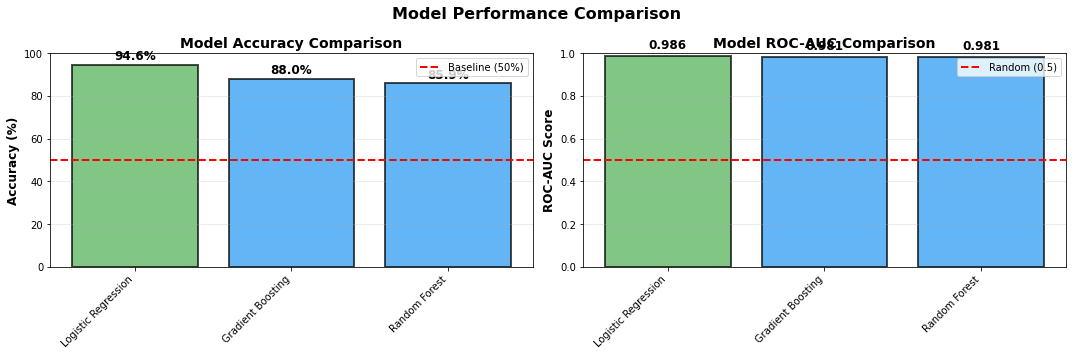

In [53]:
# Dictionary to store models and results
models= {}
results= {}

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression()
lr= LogisticRegression(random_state= 42, max_iter= 1000)
lr.fit(X_train_sc, y_train)

# Predictions
y_pred_lr= lr.predict(X_test_sc)
y_pred_proba_lr= lr.predict_proba(X_test_sc)[:, 1]

# Metrics
accuracy_lr= accuracy_score(y_test, y_pred_lr)
roc_auc_lr= roc_auc_score(y_test, y_pred_proba_lr)

print(f"   Accuracy: {accuracy_lr*100:.2f}%")
print(f"   ROC-AUC Score: {roc_auc_lr:.3f}")

models['Logistic Regression']= lr
results['Logistic Regression']= {
    'accuracy': accuracy_lr,
    'roc_auc': roc_auc_lr,
    'y_pred': y_pred_lr,
    'y_pred_proba': y_pred_proba_lr
}

# ============================================================
# MODEL 2: RANDOM FOREST
# ============================================================
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(n_estimators= 100, max_depth= 10, random_state= 42, n_jobs= -1)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf= rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
accuracy_rf= accuracy_score(y_test, y_pred_rf)
roc_auc_rf= roc_auc_score(y_test, y_pred_proba_rf)

print(f"   Accuracy: {accuracy_rf*100:.2f}%")
print(f"   ROC-AUC Score: {roc_auc_rf:.3f}")

models['Random Forest']= rf
results['Random Forest']= {
    'accuracy': accuracy_rf,
    'roc_auc': roc_auc_rf,
    'y_pred': y_pred_rf,
    'y_pred_proba': y_pred_proba_rf
}

# ============================================================
# MODEL 3: GRADIENT BOOSTING
# ============================================================
from sklearn.ensemble import GradientBoostingClassifier
gb= GradientBoostingClassifier(n_estimators= 100, learning_rate= 0.1, max_depth= 5, random_state= 42)
gb.fit(X_train, y_train)

# Predictions
y_pred_gb= gb.predict(X_test)
y_pred_proba_gb= gb.predict_proba(X_test)[:, 1]

# Metrics
accuracy_gb= accuracy_score(y_test, y_pred_gb)
roc_auc_gb= roc_auc_score(y_test, y_pred_proba_gb)

print(f"   Accuracy: {accuracy_gb*100:.2f}%")
print(f"   ROC-AUC Score: {roc_auc_gb:.3f}")

models['Gradient Boosting']= gb
results['Gradient Boosting']= {
    'accuracy': accuracy_gb,
    'roc_auc': roc_auc_gb,
    'y_pred': y_pred_gb,
    'y_pred_proba': y_pred_proba_gb
}

# ============================================================
# COMPARE ALL MODELS
# ============================================================
print(f"\n {'='*60}")
print("MODEL COMPARISON")
print("="*60)

comparison_df= pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_gb],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_gb]
})

comparison_df= comparison_df.sort_values('Accuracy', ascending= False)
print(f"\n {comparison_df.to_string(index= False)}")

# Find best model
best_model= comparison_df.iloc[0]['Model']
best_accuracy= comparison_df.iloc[0]['Accuracy']
best_roc_auc= comparison_df.iloc[0]['ROC-AUC']

print(f"\n {'='*60}")
print(f"BEST MODEL: {best_model}")
print("="*60)
print(f"   Accuracy: {best_accuracy*100:.2f}%")
print(f"   ROC-AUC: {best_roc_auc:.3f}")

# Visualization
fig, axes= plt.subplots(1, 2, figsize= (15, 5))
fig.suptitle('Model Performance Comparison', fontsize= 16, fontweight= 'bold')

# 1. Accuracy comparison
model_names= comparison_df['Model'].values
accuracies= comparison_df['Accuracy'].values * 100

colors= ['#4CAF50' if i == 0 else '#2196F3' for i in range(len(model_names))]
bars= axes[0].bar(range(len(model_names)), accuracies, color= colors, alpha= 0.7, edgecolor= 'black', linewidth= 2)
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names, rotation= 45, ha= 'right')
axes[0].set_ylabel('Accuracy (%)', fontsize= 12, fontweight= 'bold')
axes[0].set_title('Model Accuracy Comparison', fontsize= 14, fontweight= 'bold')
axes[0].set_ylim(0, 100)
axes[0].axhline(y= 50, color= 'red', linestyle= '--', linewidth= 2, label= 'Baseline (50%)')
axes[0].legend()
axes[0].grid(axis= 'y', alpha= 0.3)

# Add value labels
for bar, acc in zip(bars, accuracies):
    height= bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{acc:.1f}%',
                ha= 'center', va= 'bottom', fontsize= 12, fontweight= 'bold')

# 2. ROC-AUC comparison
roc_aucs= comparison_df['ROC-AUC'].values

bars= axes[1].bar(range(len(model_names)), roc_aucs, color=colors, alpha= 0.7, edgecolor= 'black', linewidth= 2)
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names, rotation= 45, ha= 'right')
axes[1].set_ylabel('ROC-AUC Score', fontsize= 12, fontweight= 'bold')
axes[1].set_title('Model ROC-AUC Comparison', fontsize= 14, fontweight= 'bold')
axes[1].set_ylim(0, 1)
axes[1].axhline(y= 0.5, color= 'red', linestyle= '--', linewidth= 2, label= 'Random (0.5)')
axes[1].legend()
axes[1].grid(axis= 'y', alpha= 0.3)

# Add value labels
for bar, roc in zip(bars, roc_aucs):
    height= bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{roc:.3f}',
                ha= 'center', va= 'bottom', fontsize= 12, fontweight= 'bold')

plt.tight_layout()
plt.show()

### Model Evaluation & Detailed Analysis


Focusing on BEST MODEL: Logistic Regression
Accuracy: 94.57%
ROC-AUC: 0.986

                 Predicted
                Loss   Win
Actual Loss       41     4
Actual Win         1    46

 Breakdown:
   True Negatives (TN):   41 - Correctly predicted LOSSES
   False Positives (FP):   4 - Incorrectly predicted WINS (Type I error)
   False Negatives (FN):   1 - Incorrectly predicted LOSSES (Type II error)
   True Positives (TP):   46 - Correctly predicted WINS

 Model Errors:
   Total wrong predictions: 5 out of 92
   Error rate: 5.43%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Loss       0.98      0.91      0.94        45
         Win       0.92      0.98      0.95        47

    accuracy                           0.95        92
   macro avg       0.95      0.94      0.95        92
weighted avg       0.95      0.95      0.95        92



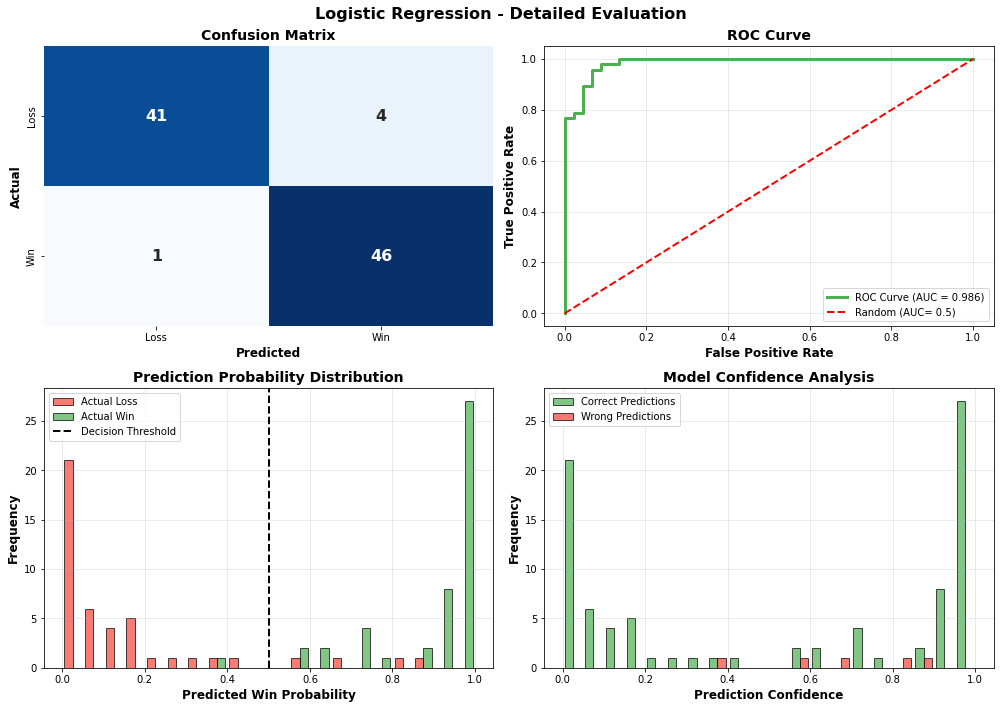

In [54]:
print(f"\nFocusing on BEST MODEL: Logistic Regression")
print(f"Accuracy: {best_accuracy*100:.2f}%")
print(f"ROC-AUC: {best_roc_auc:.3f}")

# Get predictions for Logistic Regression
y_pred= results['Logistic Regression']['y_pred']
y_pred_proba= results['Logistic Regression']['y_pred_proba']

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm= confusion_matrix(y_test, y_pred)

print(f"\n                 Predicted")
print(f"                Loss   Win")
print(f"Actual Loss     {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"Actual Win      {cm[1,0]:4d}  {cm[1,1]:4d}")

# Calculate metrics from confusion matrix
tn, fp, fn, tp= cm.ravel()

print(f"\n Breakdown:")
print(f"   True Negatives (TN):  {tn:3d} - Correctly predicted LOSSES")
print(f"   False Positives (FP): {fp:3d} - Incorrectly predicted WINS (Type I error)")
print(f"   False Negatives (FN): {fn:3d} - Incorrectly predicted LOSSES (Type II error)")
print(f"   True Positives (TP):  {tp:3d} - Correctly predicted WINS")

print(f"\n Model Errors:")
print(f"   Total wrong predictions: {fp + fn} out of {len(y_test)}")
print(f"   Error rate: {(fp + fn) / len(y_test) * 100:.2f}%")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
print(f"\n {'='*60}")
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(y_test, y_pred, target_names= ['Loss', 'Win']))

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes= plt.subplots(2, 2, figsize= (14, 10))
fig.suptitle('Logistic Regression - Detailed Evaluation', fontsize= 16, fontweight= 'bold')

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot= True, fmt= 'd', cmap= 'Blues', 
            xticklabels= ['Loss', 'Win'],
            yticklabels= ['Loss', 'Win'],
            cbar= False, ax= axes[0, 0], 
            annot_kws= {'size': 16, 'weight': 'bold'})
axes[0, 0].set_xlabel('Predicted', fontsize= 12, fontweight= 'bold')
axes[0, 0].set_ylabel('Actual', fontsize= 12, fontweight= 'bold')
axes[0, 0].set_title('Confusion Matrix', fontsize= 14, fontweight= 'bold')

# 2. ROC Curve
fpr, tpr, thresholds= roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, color= '#4CAF50', linewidth= 3, label= f'ROC Curve (AUC = {roc_auc_lr:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color= 'red', linestyle= '--', linewidth= 2, label= 'Random (AUC= 0.5)')
axes[0, 1].set_xlabel('False Positive Rate', fontsize= 12, fontweight= 'bold')
axes[0, 1].set_ylabel('True Positive Rate', fontsize= 12, fontweight= 'bold')
axes[0, 1].set_title('ROC Curve', fontsize= 14, fontweight= 'bold')
axes[0, 1].legend(loc= 'lower right')
axes[0, 1].grid(alpha= 0.3)

# 3. Prediction Probability Distribution
axes[1, 0].hist([y_pred_proba[y_test== 0], y_pred_proba[y_test == 1]], 
                bins= 20, label= ['Actual Loss', 'Actual Win'],
                color= ['#F44336', '#4CAF50'], alpha= 0.7, edgecolor= 'black')
axes[1, 0].axvline(x= 0.5, color= 'black', linestyle= '--', linewidth= 2, label= 'Decision Threshold')
axes[1, 0].set_xlabel('Predicted Win Probability', fontsize= 12, fontweight= 'bold')
axes[1, 0].set_ylabel('Frequency', fontsize= 12, fontweight= 'bold')
axes[1, 0].set_title('Prediction Probability Distribution', fontsize= 14, fontweight= 'bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha= 0.3)

# 4. Prediction Confidence
correct= (y_pred == y_test)
axes[1, 1].hist([y_pred_proba[correct], y_pred_proba[~correct]], 
                bins= 20, label= ['Correct Predictions', 'Wrong Predictions'],
                color= ['#4CAF50', '#F44336'], alpha= 0.7, edgecolor= 'black')
axes[1, 1].set_xlabel('Prediction Confidence', fontsize= 12, fontweight= 'bold')
axes[1, 1].set_ylabel('Frequency', fontsize= 12, fontweight= 'bold')
axes[1, 1].set_title('Model Confidence Analysis', fontsize= 14, fontweight= 'bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha= 0.3)

plt.tight_layout()
plt.show()